In [1]:
import networkx as nx
import seaborn as sns

from epilink import (
    EpiLink,
    NaturalHistoryParameters,
    InfectiousnessToTransmission,
    simulate_epidemic_dates,
    simulate_genomic_sequences,
    build_pairwise_case_table,
)

In [2]:
parameters = NaturalHistoryParameters()
profile = InfectiousnessToTransmission(parameters=parameters)
epilink = EpiLink(
    profile,
    maximum_depth = 2,
    target = ["ad(0)", "ca(0,0)"],
    mutation_process = "stochastic",
)
scorer = epilink.pairwise_model()

tree = nx.read_gml("transmission_tree.gml")
tree = simulate_epidemic_dates(profile, tree)
genome = simulate_genomic_sequences(profile, tree)
pairwise = build_pairwise_case_table(genome["packed"], tree)

In [8]:
pairwise.columns

Index(['CaseA', 'CaseB', 'IsRelated', 'BothSampled', 'DeterministicDistance',
       'StochasticDistance', 'SamplingDateDistanceDays',
       'DeterministicCompatibility', 'StochasticCompatibility'],
      dtype='str')

In [4]:
pairwise["DeterministicCompatibility"] = scorer(
    sample_time_difference=pairwise["DeterministicDistance"],
    genetic_distance=pairwise["SamplingDateDistanceDays"]
)

pairwise["StochasticCompatibility"] = scorer(
    sample_time_difference=pairwise["StochasticDistance"],
    genetic_distance=pairwise["SamplingDateDistanceDays"]
)

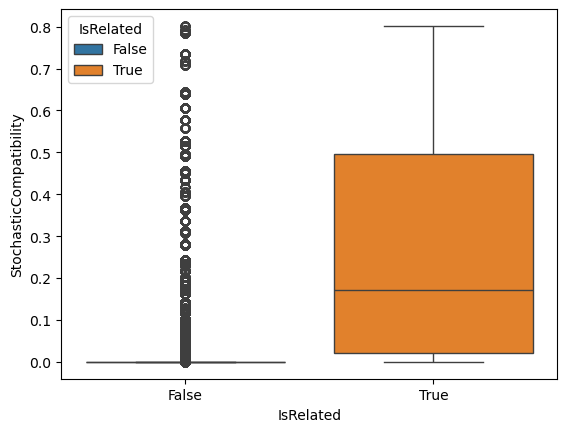

In [5]:
sns.boxplot(
    data = pairwise,
    x = "IsRelated",
    y = "StochasticCompatibility",
    hue = "IsRelated",
);

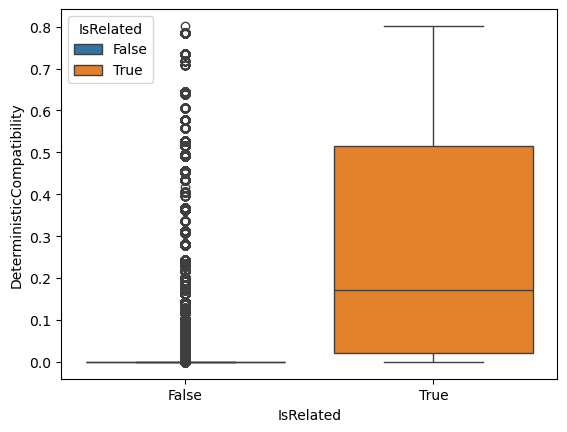

In [6]:
sns.boxplot(
    data = pairwise,
    x = "IsRelated",
    y = "DeterministicCompatibility",
    hue = "IsRelated",
);